In [18]:
!pip install ipywidgets matplotlib

import pandas as pd
import re
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline
import json
import matplotlib.pyplot as plt

df = pd.read_csv("tweets.csv")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


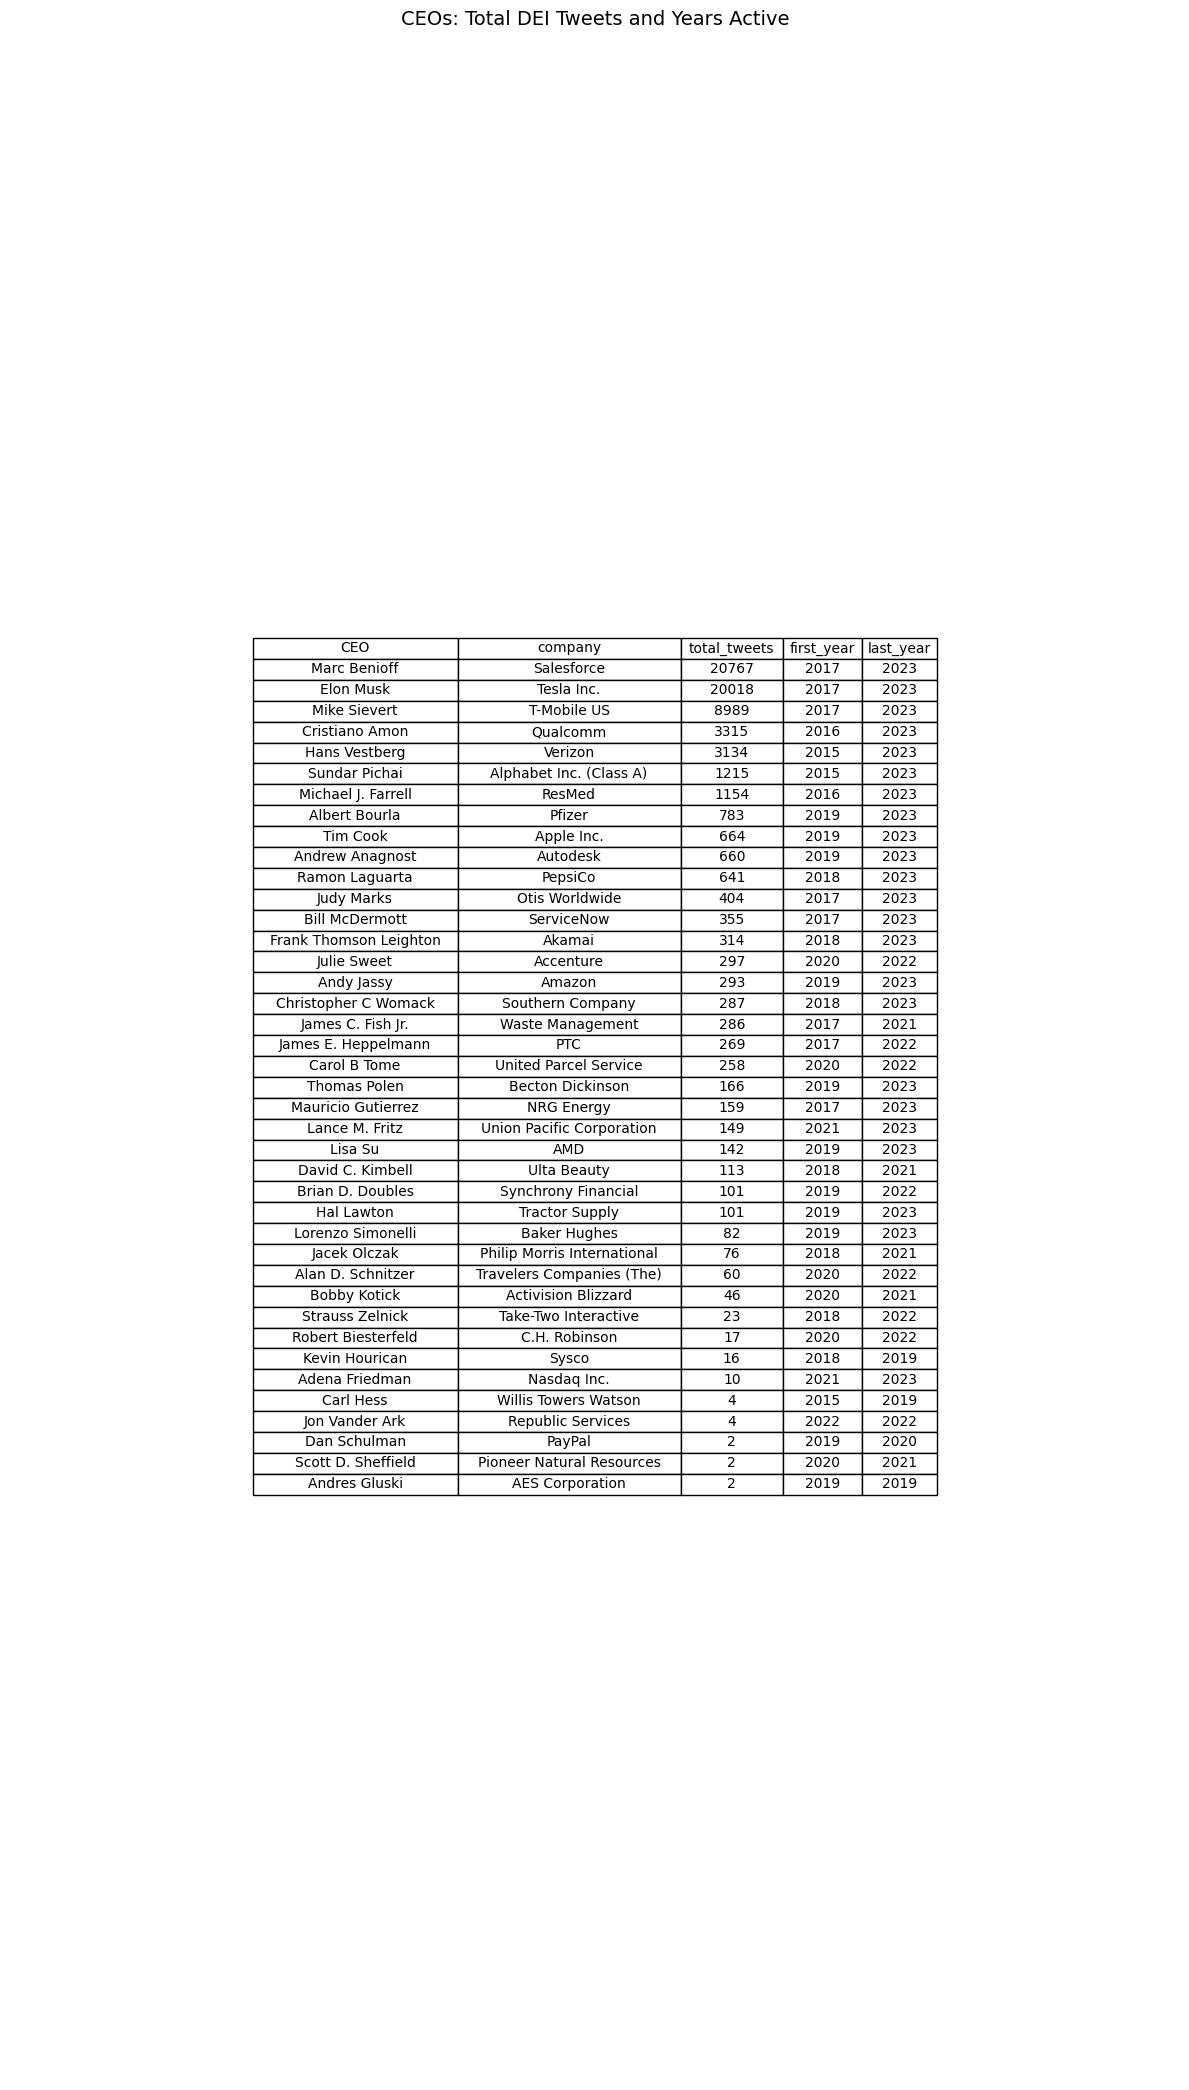

In [19]:
# ---------------- Tweets per CEO overview ---------------- #

ceo_summary = df.groupby(['CEO', 'company']).agg(
    total_tweets=('id', 'count'),
    first_year=('year', 'min'),
    last_year=('year', 'max')
).reset_index()
ceo_summary = ceo_summary.sort_values('total_tweets', ascending=False)

fig, ax = plt.subplots(figsize=(12, len(ceo_summary)*0.5 + 1))
ax.axis('off')

table = ax.table(
    cellText=ceo_summary.values,
    colLabels=ceo_summary.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(ceo_summary.columns))))

plt.title("CEOs: Total DEI Tweets and Years Active", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [20]:
# --------- Method 1: Dictionary (1281) ---------

# Exhaustive DEI terms + variations + adjacent themes
dei_keywords = [
    r"\bDEI\b", r"\bD\.E\.I\b", r"diversity", r"diverse", r"equity", r"inclusion",
    r"inclusive", r"belonging", r"represent", r"representation", r"underrepresented",
    r"employee resource group", r"\bERG\b", r"ergs", r"allyship", r"anti-?racis(?:t|m)",
    r"\bwoke\b", r"discrimination", r"bias", r"unconscious bias", r"intersectional(?:ity)?",
    r"gender equality", r"racial justice", r"racial equity", r"equal pay", r"pay gap",
    r"glass ceiling", r"equal opportunity", r"accessibility", r"accessible workplace",
    r"affirmative action", r"board diversity", r"workforce diversity", r"inclusion report",
    r"diversity report", r"diversity metrics", r"inclusion metrics", r"social impact",
    r"\bLGBTQ\+?\b", r"disabilit(?:y|ies)", r"racially diverse", r"culturally diverse",
    r"minority representation", r"marginalised", r"esg", r"social equity", r"inclusivity"
]

# Combine into one regex pattern
pattern = re.compile("|".join(dei_keywords), flags=re.IGNORECASE)

# Filter rows where text contains any DEI keyword
dei_tweets_1 = df[df["text"].fillna("").str.contains(pattern, regex=True)]

# Print summary
print(f"Total DEI-related tweets found: {len(dei_tweets_1)}\n")

# Print 10 examples (if available)
print("Sample DEI-related tweets:\n")
print(dei_tweets_1[["id", "company", "CEO", "text"]].head(10).to_string(index=False))

Total DEI-related tweets found: 1281

Sample DEI-related tweets:

                 id    company                CEO                                                                                                                                                                                                                                                                                      text
1633868613613662208     ResMed Michael J. Farrell        Happy to be here at Lake Nona Institute Forum hearing from Dr. Montgomery Rice with her take on Health Equity including her work with the Common Spirit alliance to create 7 new medical campuses around the country  expanding the pipeline of medical staff. LNIF23 HealthEquity
1636023459946934278 Salesforce       Marc Benioff                 The Deep Sea is a trove of biodiversity critical in regulating our climate amp; it faces threats from pollution, warming, acidification amp; seabed mining. Lets prioritize protecting our oceans amp; their

In [21]:
# --------- Method 2: Semantic search (1205) ---------

# Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Embed all tweet text (ignore empty rows if any remain)
tweet_embeddings = model.encode(df["text"].fillna("").tolist(), convert_to_tensor=True)

# Craft a strong DEI semantic query
dei_query = """
Diversity, equity and inclusion in the workplace, including equal opportunity,
fair wages, representation of marginalised communities, accessibility support,
employee resource groups, gender and racial equality, and fostering a sense of belonging.
"""

# Embed the semantic query
query_embedding = model.encode(dei_query, convert_to_tensor=True)

# Compute cosine similarities
similarities = util.cos_sim(query_embedding, tweet_embeddings)[0]

# Add similarity scores to dataframe
df["dei_score"] = similarities.cpu().numpy()

# Filter by a threshold OR take top-N (here we do both)
threshold = 0.25  # you can adjust this later based on results
dei_tweets_2 = df[df["dei_score"] > threshold].copy()

# Also sort by score to view the most relevant first
dei_tweets_2 = dei_tweets_2.sort_values("dei_score", ascending=False)

print(f"Total semantically DEI-related tweets found: {len(dei_tweets_2)}\n")

# Print 10 sample matches with scores
print("Top 10 sample DEI semantically matched tweets:\n")
print(
    dei_tweets_2[["id", "CEO", "company", "dei_score", "text"]]
    .head(10)
    .to_string(index=False)
)

Total semantically DEI-related tweets found: 1193

Top 10 sample DEI semantically matched tweets:

                 id                    CEO             company  dei_score                                                                                                                                                                                                                                                        text
1385668558340952068          Albert Bourla              Pfizer   0.651534                                                    Workplace diversity, equity and inclusion have never been more important. While there’s still much to do, I am #PfizerProud of the progress we have made and our work to push for continued improvement.
1276212967122624513       Brian D. Doubles Synchrony Financial   0.615209                   Diversity and inclusion remain front and center at Synchrony. Were committed to bringing together diverse voices and perspectives from across our organizatio

In [ ]:
# --------- Method 3: Zero-Shot Classification (UNUSED) ---------

# Load free zero-shot model
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Candidate DEI topic labels (exhaustive, good coverage)
dei_labels = [
    "diversity and inclusion",
    "equity and fairness",
    "workplace belonging",
    "gender equality",
    "racial equality",
    "equal opportunity hiring",
    "pay gap and fair wages",
    "accessibility support",
    "employee resource groups (ERGs)",
    "inclusive workplace culture",
    "marginalised community representation",
    "anti-discrimination policies",
    "DEI initiatives",
    "unconscious bias training",
    "LGBTQ+ inclusion",
    "disability inclusion"
]

# Run classification for each tweet
results = []
for text in df["text"].fillna("").tolist():
    if not text.strip():
        results.append(None)
        continue

    output = classifier(text, dei_labels, multi_label=True)
    # We take the maximum score across all DEI labels to represent a general "DEI relevance score"
    max_dei_score = max(output["scores"])
    results.append(max_dei_score)

df["dei_zero_shot_score"] = results

# Define threshold for DEI relevance
threshold = 0.40  # adjust later if needed
dei_tweets_3 = df[df["dei_zero_shot_score"] > threshold].copy()
dei_tweets_3 = dei_tweets_3.sort_values("dei_zero_shot_score", ascending=False)

print(f"Total DEI-classified tweets: {len(dei_tweets_3)}\n")

# Print 10 examples
print("10 sample DEI-related tweets (zero-shot):\n")
print(
    dei_tweets_3[["id", "CEO", "company", "dei_zero_shot_score", "text"]]
    .head(10)
    .to_string(index=False)
)

In [23]:
# --------- Compare search methods --------- #

# Ensure IDs are strings
dei_tweets_1 = dei_tweets_1.copy()
dei_tweets_1["id"] = dei_tweets_1["id"].astype(str)

dei_tweets_2 = dei_tweets_2.copy()
dei_tweets_2["id"] = dei_tweets_2["id"].astype(str)

# Collect ALL IDs including duplicates, preserving order
method1_ids = dei_tweets_1["id"].tolist()
method2_ids = dei_tweets_2["id"].tolist()

# Build JSON structure with ALL IDs associated with method
json_output = []

for t_id in method1_ids:
    json_output.append({"id": t_id, "method": 1})

for t_id in method2_ids:
    json_output.append({"id": t_id, "method": 2})

with open("dei_all_ids_by_method.json", "w", encoding="utf-8") as f:
    json.dump(json_output, f, indent=2, ensure_ascii=False)

print("Saved all IDs associated with method to: dei_all_ids_by_method.json")

# Compute intersection (for info only)
common_all = set(method1_ids) & set(method2_ids)
print(f"Tweets in common across ALL 2 methods: {len(common_all)}\n")

# Merge all, deduplicate by ID, and save CSV
merged_df = pd.concat([dei_tweets_1, dei_tweets_2], ignore_index=True)
before = len(merged_df)
merged_df["id"] = merged_df["id"].astype(str)
merged_df = merged_df.drop_duplicates(subset=["id"])
after = len(merged_df)

merged_df.to_csv("dei_tweets_merged.csv", index=False)

print(f"Total unique DEI tweets after deduplication: {after} ({(after/len(df))*100:.2f}%)")

Saved all IDs associated with method to: dei_all_ids_by_method.json
Tweets in common across ALL 2 methods: 448

Total unique DEI tweets after deduplication: 2026 (3.10%)
